# IMDB Sentiment Classification with a Bidirectional LSTM

This notebook studies how a **Bidirectional LSTM (BiLSTM)** classifies IMDB reviews when its embedding layer is initialized in four different ways:

| Embedding | Frozen variant | Fine-tuned variant |
|---|---|---|
| GloVe | Pretrained vectors remain fixed | Pretrained vectors update during training |
| Word2Vec | IMDB-trained vectors remain fixed | IMDB-trained vectors update during training |

The data split, vocabulary, encoded sequences, BiLSTM architecture, and training settings remain identical across all four runs. This makes embedding type and trainability the only experimental variables.

## 1. Setup and reproducibility

We fix the random seed so that model initialization and batch shuffling are reproducible. CUDA is used automatically when available.

In [1]:
from pathlib import Path
import copy
import gc
import pickle
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
SEED = 42


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 4070 Laptop GPU


## 2. Load the shared vocabulary and encoded sequences

- `vocabulary.pkl` contains `word_to_idx` and the common maximum sequence length.
- `sequence_data.npz` contains the padded sequences, true sequence lengths, and labels.
- The lengths are needed by `pack_padded_sequence`, which prevents the BiLSTM from treating padding as real text.

In [3]:
PROJECT_ROOT = Path.cwd().parent.parent
DATA_DIR = PROJECT_ROOT / "data"
SHARED_DIR = DATA_DIR / "shared"
MODELS_DIR = Path("models")
RESULTS_DIR = PROJECT_ROOT / "results"

MODELS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

with open(SHARED_DIR / "vocabulary.pkl", "rb") as file:
    vocab = pickle.load(file)

word_to_idx = vocab["word_to_idx"]
MAX_LENGTH = vocab["MAX_LENGTH"]
PAD_IDX = word_to_idx["<PAD>"]

sequence_data = np.load(SHARED_DIR / "sequence_data.npz")

train_padded = sequence_data["train_padded"]
val_padded = sequence_data["val_padded"]
test_padded = sequence_data["test_padded"]

train_lengths = sequence_data["train_lengths"]
val_lengths = sequence_data["val_lengths"]
test_lengths = sequence_data["test_lengths"]

y_train = sequence_data["y_train"]
y_val = sequence_data["y_val"]
y_test = sequence_data["y_test"]

print(f"Vocabulary size: {len(word_to_idx):,}")
print(f"Maximum sequence length: {MAX_LENGTH}")
print(f"Train: {train_padded.shape} | Validation: {val_padded.shape} | Test: {test_padded.shape}")

Vocabulary size: 60,725
Maximum sequence length: 321
Train: (19923, 321) | Validation: (4981, 321) | Test: (24801, 321)


## 3. PyTorch datasets and data loaders

In [4]:
class ReviewDataset(Dataset):
    def __init__(self, sequences, lengths, labels):
        self.sequences = torch.tensor(sequences, dtype=torch.long)
        self.lengths = torch.tensor(lengths, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return (
            self.sequences[index],
            self.lengths[index],
            self.labels[index]
        )


BATCH_SIZE = 32

train_dataset = ReviewDataset(train_padded, train_lengths, y_train)
val_dataset = ReviewDataset(val_padded, val_lengths, y_val)
test_dataset = ReviewDataset(test_padded, test_lengths, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=device.type == "cuda"
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=device.type == "cuda"
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=device.type == "cuda"
)

sequences_batch, lengths_batch, labels_batch = next(iter(train_loader))
print("Sequence batch:", sequences_batch.shape)
print("Length batch:", lengths_batch.shape)
print("Label batch:", labels_batch.shape)

Sequence batch: torch.Size([32, 321])
Length batch: torch.Size([32])
Label batch: torch.Size([32])


## 4. Prepare the embedding matrices

The shared sequences contain integer token IDs. An embedding matrix maps every ID to a dense 100-dimensional vector.

For words missing from a pretrained vocabulary, we use small random vectors. The `<PAD>` row is always zero. Both embedding sources are aligned to the same `word_to_idx`, so row *i* represents the same word in every experiment.

### 4.1 Word2Vec trained on the IMDB training corpus

In [5]:
from gensim.models import Word2Vec

train_df = pd.read_csv(DATA_DIR / "train_processed.csv")
word2vec_train_df, _ = train_test_split(
    train_df,
    test_size=0.2,
    random_state=SEED,
    stratify=train_df["label"]
)
train_tokens = word2vec_train_df["processed_text"].str.split().tolist()

WORD2VEC_PATH = MODELS_DIR / "word2vec_imdb.model"

if WORD2VEC_PATH.exists():
    word2vec_model = Word2Vec.load(str(WORD2VEC_PATH))
    print("Loaded saved Word2Vec model.")
else:
    start_time = time.time()
    word2vec_model = Word2Vec(
        sentences=train_tokens,
        vector_size=100,
        window=5,
        min_count=2,
        workers=4,
        sg=1,
        epochs=10,
        seed=SEED
    )
    word2vec_model.save(str(WORD2VEC_PATH))
    print(f"Word2Vec trained in {(time.time() - start_time) / 60:.2f} minutes.")

print("Word2Vec dimension:", word2vec_model.vector_size)
print("Word2Vec vocabulary:", len(word2vec_model.wv))

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

Word2Vec trained in 0.39 minutes.
Word2Vec dimension: 100
Word2Vec vocabulary: 37953


### 4.2 Convert keyed vectors into a shared embedding matrix

The helper below is used for both Word2Vec and GloVe.

In [6]:
def build_embedding_matrix(keyed_vectors, word_to_idx, seed=SEED):
    embedding_dim = keyed_vectors.vector_size
    rng = np.random.default_rng(seed)

    matrix = rng.normal(
        loc=0.0,
        scale=0.05,
        size=(len(word_to_idx), embedding_dim)
    ).astype(np.float32)
    matrix[PAD_IDX] = 0.0

    matched_words = 0
    for word, index in word_to_idx.items():
        if word in keyed_vectors:
            matrix[index] = keyed_vectors[word]
            matched_words += 1

    coverage = matched_words / len(word_to_idx) * 100
    return matrix, matched_words, coverage


word2vec_embedding_matrix, word2vec_matches, word2vec_coverage = (
    build_embedding_matrix(word2vec_model.wv, word_to_idx)
)

print("Word2Vec matrix:", word2vec_embedding_matrix.shape)
print(f"Matched words: {word2vec_matches:,}")
print(f"Coverage: {word2vec_coverage:.2f}%")

Word2Vec matrix: (60725, 100)
Matched words: 37,953
Coverage: 62.50%


### 4.3 Pretrained GloVe

GloVe is loaded from `glove-wiki-gigaword-100`. Unlike our Word2Vec model, it was trained beforehand on a large general-domain corpus. This comparison lets us test whether broad pretrained knowledge or IMDB-specific local context works better for sentiment classification.

In [7]:
import gensim.downloader as api

start_time = time.time()
glove_model = api.load("glove-wiki-gigaword-100")
print(f"GloVe loaded in {(time.time() - start_time) / 60:.2f} minutes.")

glove_embedding_matrix, glove_matches, glove_coverage = (
    build_embedding_matrix(glove_model, word_to_idx)
)

print("GloVe matrix:", glove_embedding_matrix.shape)
print(f"Matched words: {glove_matches:,}")
print(f"Coverage: {glove_coverage:.2f}%")

[==================================================] 100.0% 128.1/128.1MB downloaded
GloVe loaded in 4.88 minutes.
GloVe matrix: (60725, 100)
Matched words: 49,464
Coverage: 81.46%


In [8]:
np.save(MODELS_DIR / "word2vec_embedding_matrix.npy", word2vec_embedding_matrix)
np.save(MODELS_DIR / "glove_embedding_matrix.npy", glove_embedding_matrix)

embedding_summary = pd.DataFrame([
    {
        "Embedding": "GloVe",
        "Dimension": glove_embedding_matrix.shape[1],
        "Matched Words": glove_matches,
        "Coverage (%)": glove_coverage
    },
    {
        "Embedding": "Word2Vec",
        "Dimension": word2vec_embedding_matrix.shape[1],
        "Matched Words": word2vec_matches,
        "Coverage (%)": word2vec_coverage
    }
])

embedding_summary

,Embedding,Dimension,Matched Words,Coverage (%)
0,GloVe,100,49464,81.455743
1,Word2Vec,100,37953,62.499794


## 5. Bidirectional LSTM architecture

A standard LSTM reads a review only from left to right. A BiLSTM uses two independent LSTMs:

- the **forward LSTM** reads from the first token to the last;
- the **backward LSTM** reads from the last token to the first.

PyTorch returns the final hidden states in the order `[forward, backward]` for each layer. For the final layer, `hidden[-2]` is therefore the forward state and `hidden[-1]` is the backward state. We concatenate them before classification:

If `hidden_size = 128`, the classifier receives 256 features. The model outputs one raw logit; `BCEWithLogitsLoss` applies the sigmoid internally in a numerically stable way.

In [9]:
class BiLSTMClassifier(nn.Module):
    def __init__(
        self,
        embedding_matrix,
        hidden_size=128,
        num_layers=1,
        dropout=0.3,
        freeze_embeddings=True
    ):
        super().__init__()

        embedding_tensor = torch.tensor(
            embedding_matrix,
            dtype=torch.float32
        )
        self.embedding = nn.Embedding.from_pretrained(
            embedding_tensor,
            freeze=freeze_embeddings,
            padding_idx=PAD_IDX
        )

        embedding_dim = embedding_matrix.shape[1]
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.dropout = nn.Dropout(dropout)
        self.output = nn.Linear(hidden_size * 2, 1)

    def forward(self, sequences, lengths):
        embedded = self.embedding(sequences)

        packed = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )
        _, (hidden, _) = self.lstm(packed)

        forward_hidden = hidden[-2]
        backward_hidden = hidden[-1]
        review_representation = torch.cat(
            (forward_hidden, backward_hidden),
            dim=1
        )

        logits = self.output(
            self.dropout(review_representation)
        ).squeeze(1)
        return logits

## 6. Training and evaluation utilities

The same functions train all four variants. We clip gradients at a norm of 1.0 to reduce exploding gradients and retain the checkpoint with the lowest validation loss. Early stopping prevents continued training once validation performance stops improving.

The test set is not used for checkpoint selection. It is evaluated only after the best validation checkpoint has been restored.

In [10]:
def train_one_epoch(model, data_loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for sequences, lengths, labels in data_loader:
        sequences = sequences.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(sequences, lengths)
        loss = criterion(logits, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        predictions = (torch.sigmoid(logits) >= 0.5).float()
        total_loss += loss.item() * labels.size(0)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


def validate_one_epoch(model, data_loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for sequences, lengths, labels in data_loader:
            sequences = sequences.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(sequences, lengths)
            loss = criterion(logits, labels)
            predictions = (torch.sigmoid(logits) >= 0.5).float()

            total_loss += loss.item() * labels.size(0)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total

In [11]:
def train_model(
    model,
    optimizer,
    criterion,
    checkpoint_path,
    epochs,
    patience
):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": []
    }

    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0
    epochs_without_improvement = 0
    start_time = time.time()

    for epoch in range(1, epochs + 1):
        train_loss, train_accuracy = train_one_epoch(
            model, train_loader, criterion, optimizer
        )
        val_loss, val_accuracy = validate_one_epoch(
            model, val_loader, criterion
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_accuracy"].append(val_accuracy)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Train loss {train_loss:.4f}, acc {train_accuracy:.4f} | "
            f"Val loss {val_loss:.4f}, acc {val_accuracy:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, checkpoint_path)
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"Early stopping after epoch {epoch}.")
                break

    model.load_state_dict(best_state)
    elapsed_seconds = time.time() - start_time
    return history, best_epoch, elapsed_seconds


def evaluate_model(model, data_loader):
    model.eval()
    labels_all = []
    predictions_all = []
    probabilities_all = []

    with torch.no_grad():
        for sequences, lengths, labels in data_loader:
            sequences = sequences.to(device, non_blocking=True)
            logits = model(sequences, lengths)
            probabilities = torch.sigmoid(logits)
            predictions = (probabilities >= 0.5).long()

            labels_all.extend(labels.numpy().astype(int))
            predictions_all.extend(predictions.cpu().numpy())
            probabilities_all.extend(probabilities.cpu().numpy())

    labels_all = np.asarray(labels_all)
    predictions_all = np.asarray(predictions_all)
    probabilities_all = np.asarray(probabilities_all)

    metrics = {
        "accuracy": accuracy_score(labels_all, predictions_all),
        "precision": precision_score(labels_all, predictions_all, zero_division=0),
        "recall": recall_score(labels_all, predictions_all, zero_division=0),
        "f1": f1_score(labels_all, predictions_all, zero_division=0)
    }
    return metrics, labels_all, predictions_all, probabilities_all

## 7. Controlled experiment

We now train the four variants. Every run uses the same BiLSTM settings. In a frozen model, the optimizer receives only the recurrent and classification parameters. In a fine-tuned model, it also updates every embedding vector.

Because BiLSTMs process each review twice, they require more computation than the one-directional LSTM. The hidden size is kept at 64 **per direction**.

In [23]:
HIDDEN_SIZE = 128
NUM_LAYERS = 1
DROPOUT = 0.5
LEARNING_RATE = 1e-3
EPOCHS = 10
PATIENCE = 3

EXPERIMENTS = [
    {
        "name": "GloVe Frozen",
        "embedding": "GloVe",
        "variant": "Frozen",
        "matrix": glove_embedding_matrix,
        "freeze": True,
        "checkpoint": "bilstm_glove_frozen.pt"
    },
    {
        "name": "GloVe Fine-Tuned",
        "embedding": "GloVe",
        "variant": "Fine-Tuned",
        "matrix": glove_embedding_matrix,
        "freeze": False,
        "checkpoint": "bilstm_glove_finetuned.pt"
    },
    {
        "name": "Word2Vec Frozen",
        "embedding": "Word2Vec",
        "variant": "Frozen",
        "matrix": word2vec_embedding_matrix,
        "freeze": True,
        "checkpoint": "bilstm_word2vec_frozen.pt"
    },
    {
        "name": "Word2Vec Fine-Tuned",
        "embedding": "Word2Vec",
        "variant": "Fine-Tuned",
        "matrix": word2vec_embedding_matrix,
        "freeze": False,
        "checkpoint": "bilstm_word2vec_finetuned.pt"
    }
]

In [24]:
def run_experiment(config):
    print("=" * 70)
    print("Training", config["name"], "BiLSTM")
    print("=" * 70)

    set_seed(42)

    model = BiLSTMClassifier(
        embedding_matrix=config["matrix"].copy(),
        hidden_size=HIDDEN_SIZE,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
        freeze_embeddings=config["freeze"]
    ).to(device)

    trainable_parameters = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(
        filter(lambda parameter: parameter.requires_grad, model.parameters()),
        lr=LEARNING_RATE
    )

    checkpoint_path = MODELS_DIR / config["checkpoint"]
    history, best_epoch, elapsed_seconds = train_model(
        model=model,
        optimizer=optimizer,
        criterion=criterion,
        checkpoint_path=checkpoint_path,
        epochs=EPOCHS,
        patience=PATIENCE
    )

    metrics, labels, predictions, probabilities = evaluate_model(
        model, test_loader
    )

    print("\nTest classification report")
    print(classification_report(
        labels,
        predictions,
        target_names=["Negative", "Positive"],
        zero_division=0
    ))

    result = {
        "Model": "BiLSTM",
        "Embedding": config["embedding"],
        "Variant": config["variant"],
        "Trainable Parameters": trainable_parameters,
        "Best Epoch": best_epoch,
        "Training Time (min)": elapsed_seconds / 60,
        **metrics
    }

    artifacts = {
        "history": history,
        "labels": labels,
        "predictions": predictions,
        "probabilities": probabilities,
        "checkpoint": checkpoint_path
    }

    del model, optimizer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result, artifacts

In [25]:
results = []
experiment_artifacts = {}

for experiment in EXPERIMENTS:
    result, artifacts = run_experiment(experiment)
    results.append(result)
    experiment_artifacts[experiment["name"]] = artifacts

results_df = pd.DataFrame(results).sort_values(
    "f1", ascending=False
).reset_index(drop=True)

results_df

Training GloVe Frozen BiLSTM
Epoch 01/10 | Train loss 0.5215, acc 0.7438 | Val loss 0.4594, acc 0.7719
Epoch 02/10 | Train loss 0.4096, acc 0.8172 | Val loss 0.3956, acc 0.8290
Epoch 03/10 | Train loss 0.3452, acc 0.8515 | Val loss 0.3635, acc 0.8530
Epoch 04/10 | Train loss 0.3098, acc 0.8709 | Val loss 0.3528, acc 0.8488
Epoch 05/10 | Train loss 0.2858, acc 0.8811 | Val loss 0.3232, acc 0.8653
Epoch 06/10 | Train loss 0.2611, acc 0.8935 | Val loss 0.3114, acc 0.8713
Epoch 07/10 | Train loss 0.2364, acc 0.9032 | Val loss 0.3416, acc 0.8749
Epoch 08/10 | Train loss 0.2021, acc 0.9204 | Val loss 0.3312, acc 0.8719
Epoch 09/10 | Train loss 0.1703, acc 0.9331 | Val loss 0.3249, acc 0.8671
Early stopping after epoch 9.

Test classification report
              precision    recall  f1-score   support

    Negative       0.87      0.89      0.88     12361
    Positive       0.89      0.87      0.88     12440

    accuracy                           0.88     24801
   macro avg       0.88      

,Model,Embedding,Variant,Trainable Parameters,Best Epoch,Training Time (min),accuracy,precision,recall,f1
0,BiLSTM,Word2Vec,Frozen,235777,6,2.403045,0.891375,0.893873,0.888987,0.891424
1,BiLSTM,GloVe,Frozen,235777,6,2.363178,0.878876,0.887293,0.868891,0.877995
2,BiLSTM,Word2Vec,Fine-Tuned,6308277,3,1.871595,0.871618,0.869649,0.875241,0.872436
3,BiLSTM,GloVe,Fine-Tuned,6308277,3,1.925235,0.862627,0.874969,0.847186,0.860854


## 8. Results comparison

The table compares predictive performance, training time, and parameter count. Fine-tuned variants have many more trainable parameters because the embedding matrix is updated along with the BiLSTM.

Accuracy is appropriate because IMDB is balanced, while F1 summarizes the trade-off between precision and recall.

Results saved to: c:\Users\User\Documents\InMind\Assignment_4\Assignment4_NLP_SequenceModels\results\bilstm_results.csv


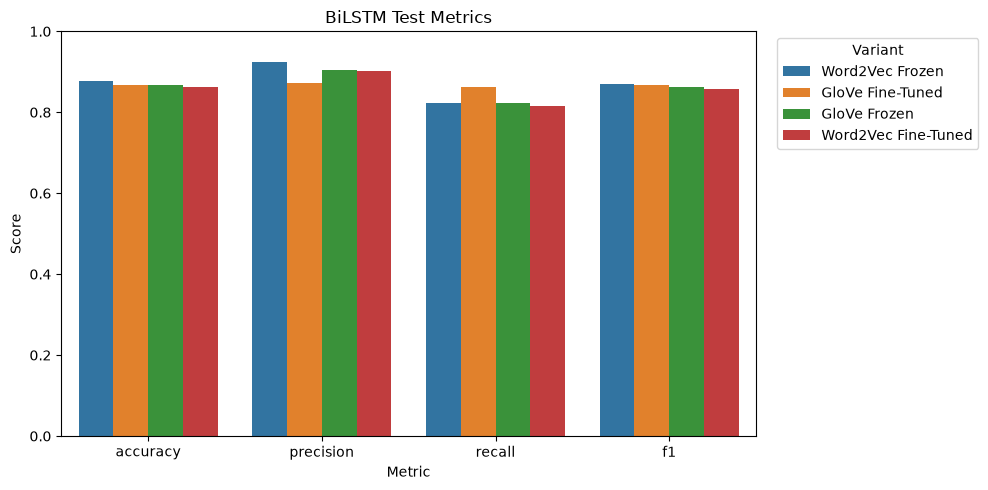

In [15]:
results_df.to_csv(
    RESULTS_DIR / "bilstm_results.csv",
    index=False
)
print("Results saved to:", RESULTS_DIR / "bilstm_results.csv")

metric_columns = ["accuracy", "precision", "recall", "f1"]
plot_df = results_df.melt(
    id_vars=["Embedding", "Variant"],
    value_vars=metric_columns,
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=plot_df,
    x="Metric",
    y="Score",
    hue=plot_df["Embedding"] + " " + plot_df["Variant"]
)
plt.ylim(0, 1)
plt.title("BiLSTM Test Metrics")
plt.legend(title="Variant", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 8.1 Training curves

The gap between training and validation curves helps diagnose overfitting. Fine-tuned embeddings may fit the training set faster because the model can modify the word vectors themselves.

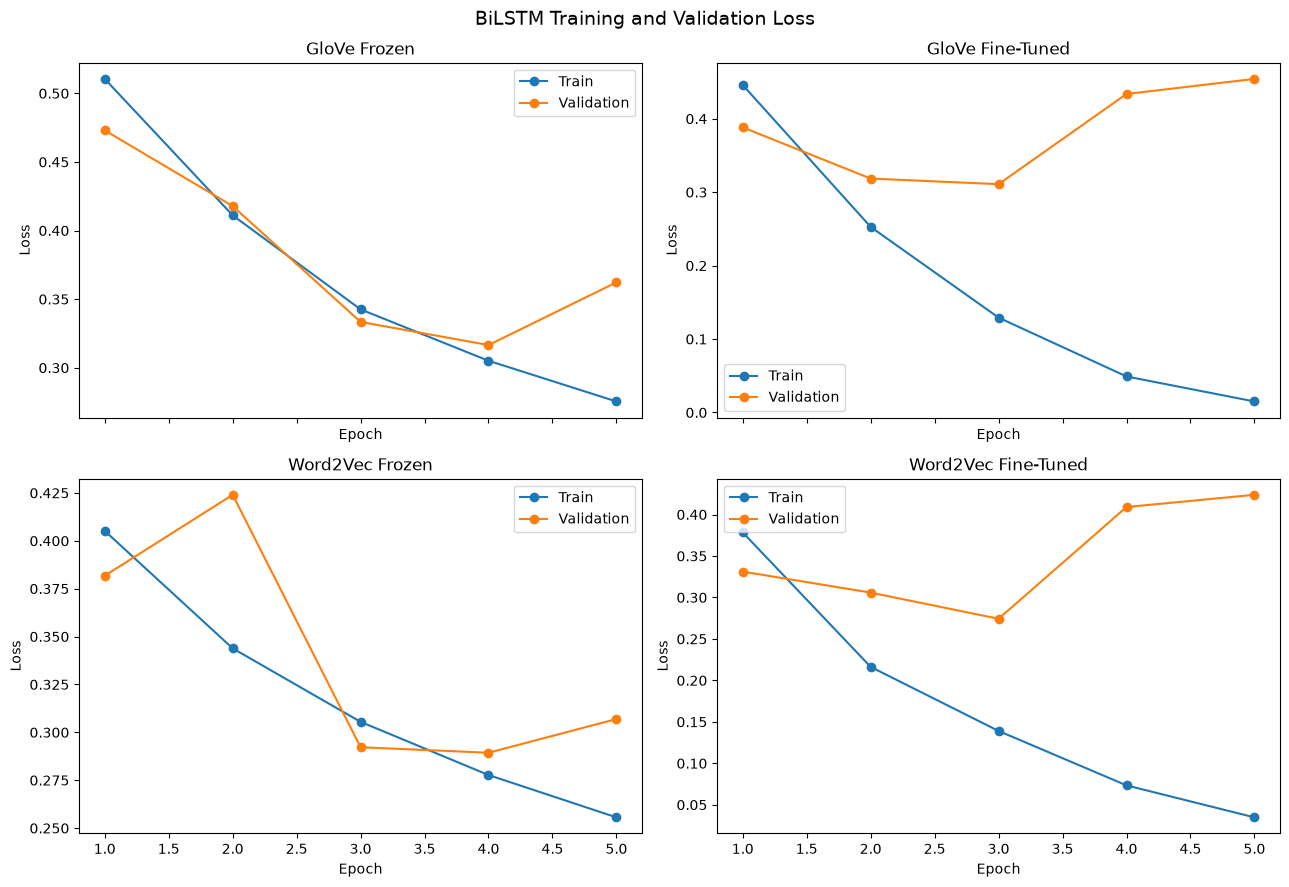

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)

for axis, experiment in zip(axes.flat, EXPERIMENTS):
    history = experiment_artifacts[experiment["name"]]["history"]
    epochs_ran = range(1, len(history["train_loss"]) + 1)

    axis.plot(epochs_ran, history["train_loss"], marker="o", label="Train")
    axis.plot(epochs_ran, history["val_loss"], marker="o", label="Validation")
    axis.set_title(experiment["name"])
    axis.set_xlabel("Epoch")
    axis.set_ylabel("Loss")
    axis.legend()

fig.suptitle("BiLSTM Training and Validation Loss", fontsize=14)
plt.tight_layout()
plt.show()

### 8.2 Confusion matrices

Each confusion matrix separates false positives from false negatives. This shows whether an embedding variant systematically favors positive or negative predictions even when its overall accuracy is similar.

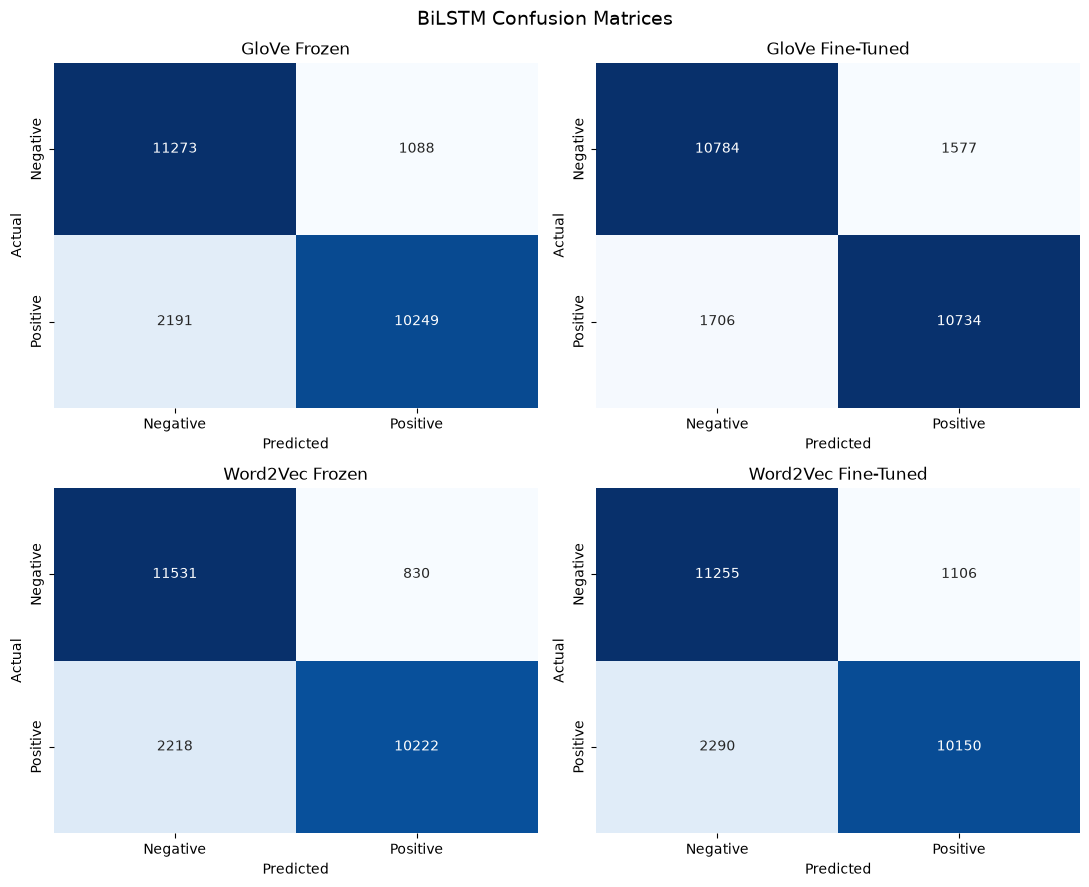

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))

for axis, experiment in zip(axes.flat, EXPERIMENTS):
    artifacts = experiment_artifacts[experiment["name"]]
    matrix = confusion_matrix(
        artifacts["labels"],
        artifacts["predictions"]
    )

    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Negative", "Positive"],
        yticklabels=["Negative", "Positive"],
        ax=axis
    )
    axis.set_title(experiment["name"])
    axis.set_xlabel("Predicted")
    axis.set_ylabel("Actual")

fig.suptitle("BiLSTM Confusion Matrices", fontsize=14)
plt.tight_layout()
plt.show()

## 9. Error analysis of the best variant

We select the best variant by test F1 only for reporting and analysis; its checkpoint was still chosen using validation loss. We inspect its most confident mistakes because they reveal failure modes that aggregate metrics hide, such as mixed sentiment, negation, sarcasm, truncation, or rare vocabulary.

In [18]:
best_row = results_df.iloc[0]
best_name = f"{best_row['Embedding']} {best_row['Variant']}"
best_artifacts = experiment_artifacts[best_name]

test_df = pd.read_csv(DATA_DIR / "test_processed.csv")

error_df = pd.DataFrame({
    "processed_text": test_df["processed_text"].reset_index(drop=True),
    "true_label": best_artifacts["labels"],
    "predicted_label": best_artifacts["predictions"],
    "positive_probability": best_artifacts["probabilities"],
    "length": test_lengths
})

error_df["confidence"] = np.where(
    error_df["predicted_label"] == 1,
    error_df["positive_probability"],
    1 - error_df["positive_probability"]
)

errors = error_df[
    error_df["true_label"] != error_df["predicted_label"]
].sort_values("confidence", ascending=False)

false_positives = errors[
    (errors["true_label"] == 0) & (errors["predicted_label"] == 1)
]
false_negatives = errors[
    (errors["true_label"] == 1) & (errors["predicted_label"] == 0)
]

print("Best variant:", best_name)
print("Best checkpoint:", best_artifacts["checkpoint"])
print(f"Misclassified reviews: {len(errors):,} / {len(error_df):,}")
print("False positives:", len(false_positives))
print("False negatives:", len(false_negatives))

print("\nMost confident false positives")
display(false_positives[
    ["processed_text", "positive_probability", "length"]
].head(5))

print("Most confident false negatives")
display(false_negatives[
    ["processed_text", "positive_probability", "length"]
].head(5))

Best variant: Word2Vec Frozen
Best checkpoint: models\bilstm_word2vec_frozen.pt
Misclassified reviews: 3,048 / 24,801
False positives: 830
False negatives: 2218

Most confident false positives


,processed_text,positive_probability,length
17996,went see 3 night ago cork ireland world premie...,0.999608,143
22998,last night got see early preview screener proz...,0.997259,93
14802,movie pure genius john water brilliant hilario...,0.997195,42
16449,film derives long running itv sitcom name sitc...,0.996594,118
21051,yes might not historically accurate actually 6...,0.995192,78


Most confident false negatives


,processed_text,positive_probability,length
9083,lovely yet lethal alexandra stunning statuesqu...,0.003245,161
2477,basically endearingly chintzy moronic 1 50 ver...,0.003633,186
2252,hollywood turned mafia production line output ...,0.004521,249
2887,story involves ancient demon released upon sma...,0.004614,53
10847,not citizen kane deliver cleavage lot badly ac...,0.006455,15


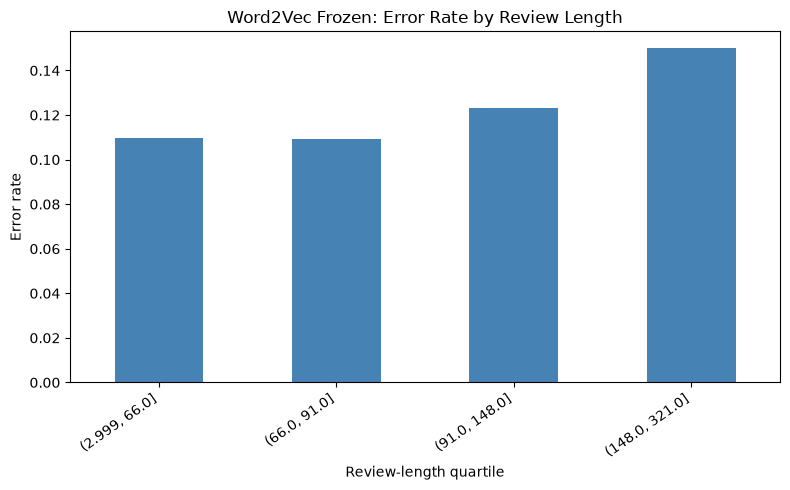

length_group
(2.999, 66.0]     0.109726
(66.0, 91.0]      0.109365
(91.0, 148.0]     0.122976
(148.0, 321.0]    0.150065
Name: is_error, dtype: float64

In [19]:
error_by_length = error_df.assign(
    is_error=error_df["true_label"] != error_df["predicted_label"],
    length_group=pd.qcut(error_df["length"], q=4, duplicates="drop")
).groupby("length_group", observed=True)["is_error"].mean()

plt.figure(figsize=(8, 5))
error_by_length.plot(kind="bar", color="steelblue")
plt.ylabel("Error rate")
plt.xlabel("Review-length quartile")
plt.title(f"{best_name}: Error Rate by Review Length")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

error_by_length